# **Çizgi, Daire ve Blob Algılama**

####**Bu derste şunları öğreneceğiz:**
1. Hough çizgileri
2. Olasılıksal Hough Çizgileri
3. Hough Daireleri
4. Blob Algılama

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Çizgi Algılama - Hough Çizgilerini Kullanma**
   
cv2.HoughLines fonksiyonu, OpenCV kütüphanesinde kullanılan bir doğru (line) tespit yöntemidir ve Hough Dönüşümü prensibine dayanır. Bu yöntem, kenar tespit edilmiş (genellikle Canny ile) bir görüntüdeki düz çizgileri bulmak için kullanılır.

`lines = cv2.HoughLines(image, rho, theta, threshold)`
## Parametreler
- image
  - Giriş görüntüsü tek kanallı (grayscale) ve genellikle kenar tespiti uygulanmış (örneğin cv2.Canny) olmalıdır.
- rho
    - Parametre alanında mesafe çözünürlüğü.
    - Piksel cinsinden ifade edilir. (Örn: 1 = 1 piksel)
- theta
    - Parametre alanında açı çözünürlüğü.
    - Radyan cinsindendir. (Örn: np.pi/180 = 1 derece)
- threshold
    - Bir çizgi olarak kabul edilmesi için gereken minimum oy sayısı.
    - Yani bir çizgi üzerinde kaç piksel hizalanırsa çizgi kabul edileceğini belirler.
## Dönen Değer
- lines : Bulunan çizgilerin (rho, theta) parametreleri.
    - Her çizgi şu şekilde temsil edilir:
        - rho: Çizgiye olan en yakın noktanın (orijine dik mesafe)
        - theta: Çizginin açısı (radyan)


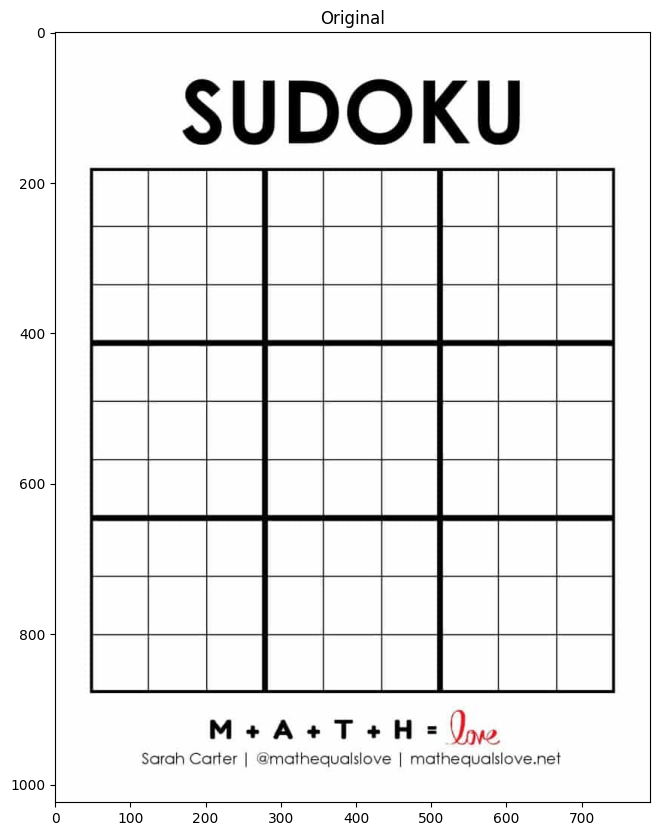

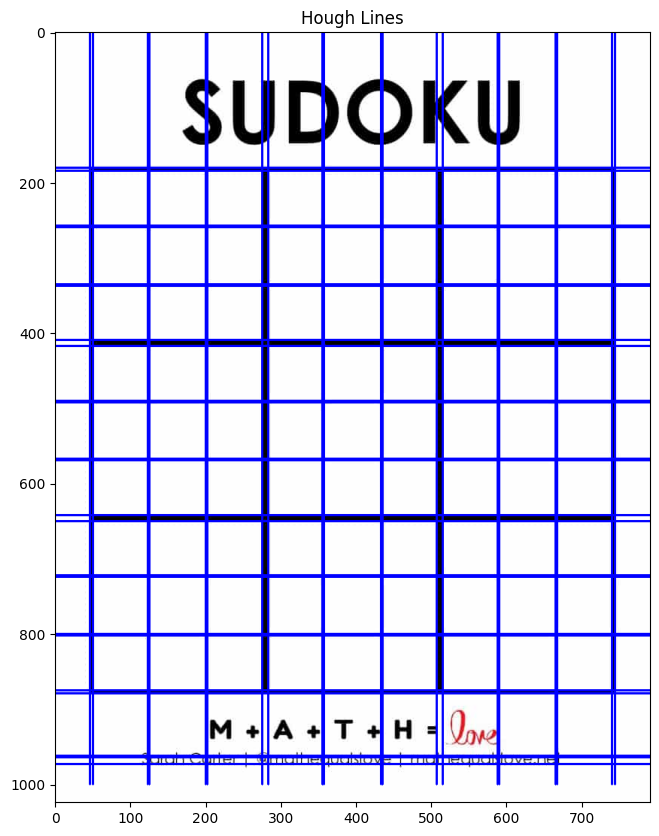

In [15]:
image = cv2.imread('../files/images/sudoku.jpg')
imshow('Original', image)

# Gri Tonlama ve Canny Edges çıkarıldı
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 170, apertureSize = 3)


# 1 piksellik bir rho doğruluğu kullanarak HoughLines'ı çalıştırın
# 1 derece olan ve np.pi / 180 ile bulunan teta doğruluğu kullanalım  
# Çizgi eşiğimiz 240 olarak ayarlanmıştır (çizgi üzerindeki nokta sayısı)
lines = cv2.HoughLines(edges, 1, np.pi / 180, 240)

# Her satırı yineliyoruz ve biçime dönüştürüyoruz
# cv2.lines tarafından gereklidir (yani uç noktaları gerektirir)
for line in lines:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

imshow('Hough Lines', image)

## **Olasılıksal Hough Çizgileri**
Bir Hough Dönüşümü, kenar noktalarının rastgele örneklemesini kullanıyorsa probabilistik olarak kabul edilir. Bu algoritmalar, görüntü uzayını parametre uzayına nasıl eşlediklerine göre ayrılabilir.

```
cv2.HoughLinesP(binarized image, 𝜌 accuracy, 𝜃 accuracy, threshold, minimum line length, max line gap)
```

(170, 1, 4)


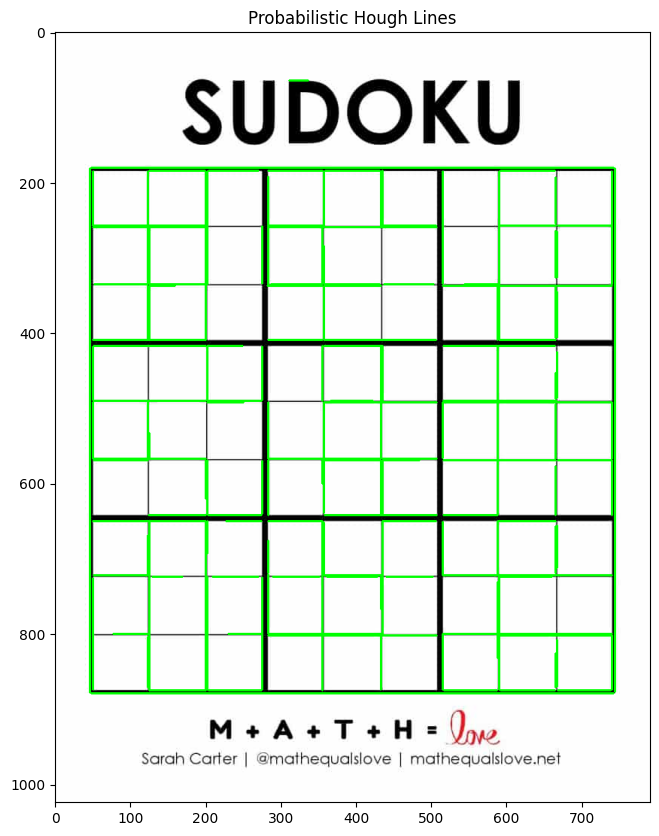

In [14]:
# Gri Tonlama ve Canny Edges çıkarıldı
image = cv2.imread('../files/images/sudoku.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 170, apertureSize = 3)

# Yine aynı rho ve teta doğruluklarını kullanıyoruz
# Bununla birlikte, minimum 100 oy (satır boyunca puanlar) belirleriz
# ve Minimum satır uzunluğu 3 piksel ve satırlar arasındaki maksimum boşluk 25 piksel
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, 3, 25)
print(lines.shape)

for x in range(0, len(lines)):
    for x1,y1,x2,y2 in lines[x]:
        cv2.line(image,(x1,y1),(x2,y2),(0,255,0),2)

imshow('Probabilistic Hough Lines', image)

## **Daire Algılama - Hough Daireleri**

**cv2.HoughCircles**(image, method, dp, MinDist, param1, param2, minRadius, MaxRadius)


- Method - şu anda sadece cv2.HOUGH_GRADIENT uygulanabilir
- dp - Akümülatör çözünürlüğünün ters oranı
- MinDist - tespit edilen dairelerin merkezleri arasındaki minimum mesafe
- param1 - Kenar algılamada kullanılan gradyan değeri
- param2 - HOUGH_GRADIENT yöntemi için akümülatör eşiği (daha düşük olması daha fazla dairenin tespit edilmesini sağlar (yanlış pozitifler))
- minRadius - en küçük daireyi bu boyutla sınırlar (yarıçap aracılığıyla)
- MaxRadius - benzer şekilde en büyük daireler için sınırı belirler

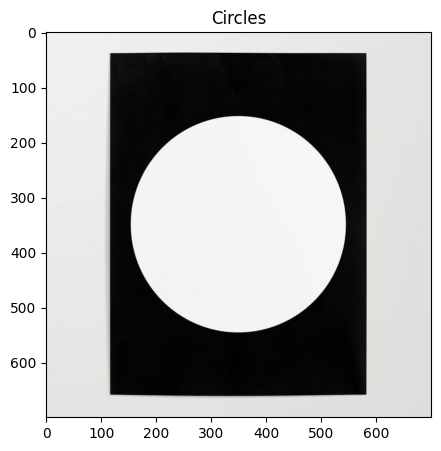

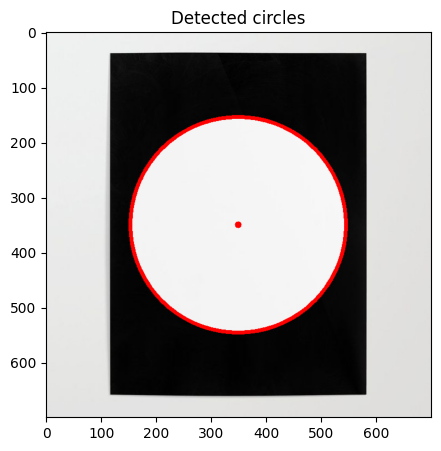

In [26]:
image = cv2.imread('../files/images/deneme3.jpg')
imshow('Circles', image,5)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.medianBlur(gray, 5)

circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, 1.2, 25)

cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1.2, 100)

circles = np.uint16(np.around(circles))

for i in circles[0,:]:
    # dış daireyi çizin
    cv2.circle(image,(i[0], i[1]), i[2], (0, 0, 255), 5)
    
    # dairenin merkezini çizin
    cv2.circle(image, (i[0], i[1]), 2, (0, 0, 255), 8)

imshow('Detected circles', image,5)

## **Blob Tespiti**

Blob: Görüntüde parlaklık, renk veya dokusu birbirine benzeyen ve birbirine bağlı piksel grubu.
Örneğin bir çiçekteki sap, yaprak üzerindeki lekeler, hücreler veya hava balonları.\
The function **cv2.drawKeypoints** takes the following arguments:

**cv2.drawKeypoints**(input image, keypoints, blank_output_array, color, flags)

flags:
- cv2.DRAW_MATCHES_FLAGS_DEFAULT
- cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
- cv2.DRAW_MATCHES_FLAGS_DRAW_OVER_OUTIMG
- cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS
- 

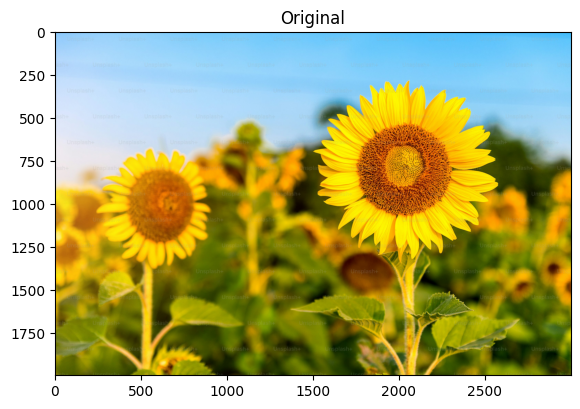

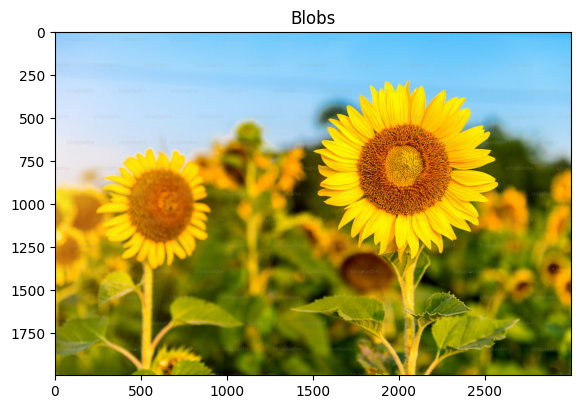

In [29]:
# Görüntüyü oku
image = cv2.imread("../files/images/deneme4.jpg")
imshow("Original", image)

# Dedektörü varsayılan parametrelerle kuralım.
detector = cv2.SimpleBlobDetector_create()
 
# Blobları tespit edin.
keypoints = detector.detect(image)
 
# Tespit edilen lekeleri kırmızı daireler olarak çizin.
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS öğesinin boyutunu sağlar
# daire blobun boyutuna karşılık gelir
blank = np.zeros((1,1)) 
blobs = cv2.drawKeypoints(image, keypoints, blank, (0,255,0),
                                      cv2.DRAW_MATCHES_FLAGS_DEFAULT)
 
# Anahtar noktaları göster
imshow("Blobs", blobs)